# Test: Fix formatting of spectrogram axis (Issue #37)
Tests the axis label fix for `plot_spectrogram_mpl` in `src/ecallisto_ng/plotting/plotting.py`.

**What we're checking:**
- Y-axis (frequency): ~8 readable ticks, not 80+
- X-axis (time): labels rotated 30°, no overlap

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Helper: count visible axis ticks

In [3]:
def get_axis_info(fig):
    ax = fig.axes[0]
    ytick_labels = [t.get_text() for t in ax.get_yticklabels() if t.get_text()]
    xtick_labels = [t.get_text() for t in ax.get_xticklabels() if t.get_text()]
    xrotation    = ax.get_xticklabels()[0].get_rotation() if xtick_labels else None
    return {
        "n_yticks": len(ytick_labels),
        "ytick_labels": ytick_labels,
        "n_xticks": len(xtick_labels),
        "xtick_labels": xtick_labels,
        "x_rotation": xrotation,
    }

## Test 1 — Wide-band, multi-day (reproduces the Brazil_01 issue)
This is the hardest case: ~330 frequency channels over 3 days.
Before the fix the y-axis had 80+ labels and x labels overlapped at 0° rotation.

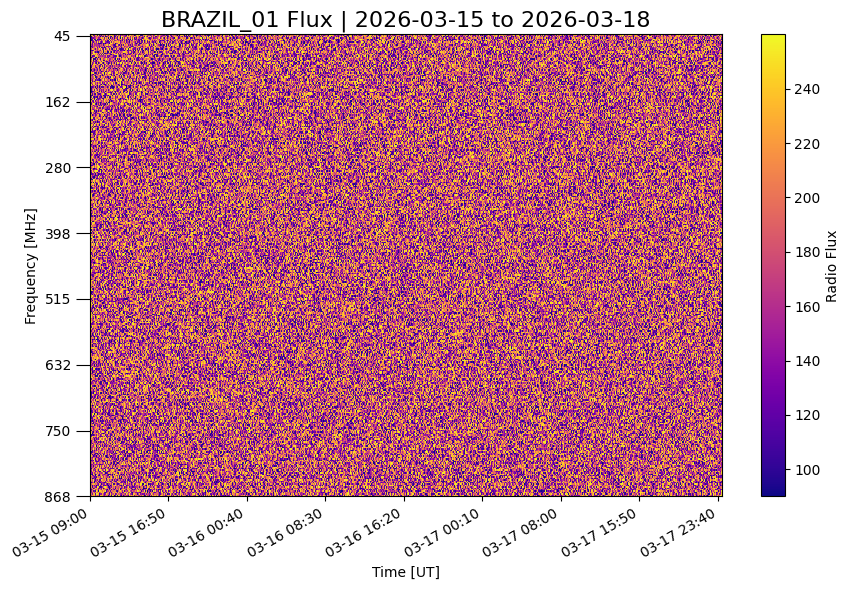

In [14]:
from src.ecallisto_ng.plotting.plotting import plot_spectrogram_mpl

np.random.seed(42)
times = pd.date_range("2026-03-15 09:00", "2026-03-18 00:00", freq="5min")
freqs = np.arange(45, 870, 2.5)   # ~330 channels
data  = np.random.uniform(90, 260, size=(len(times), len(freqs)))
df_wide = pd.DataFrame(data, index=times, columns=freqs.astype(str))

fig1 = plot_spectrogram_mpl(
    df_wide,
    instrument_name="BRAZIL_01",
    start_datetime=times[0],
    end_datetime=times[-1],
)
plt.show()

## Test 2 — Narrow-band, single day
A narrower frequency range shouldn't break the tick logic.

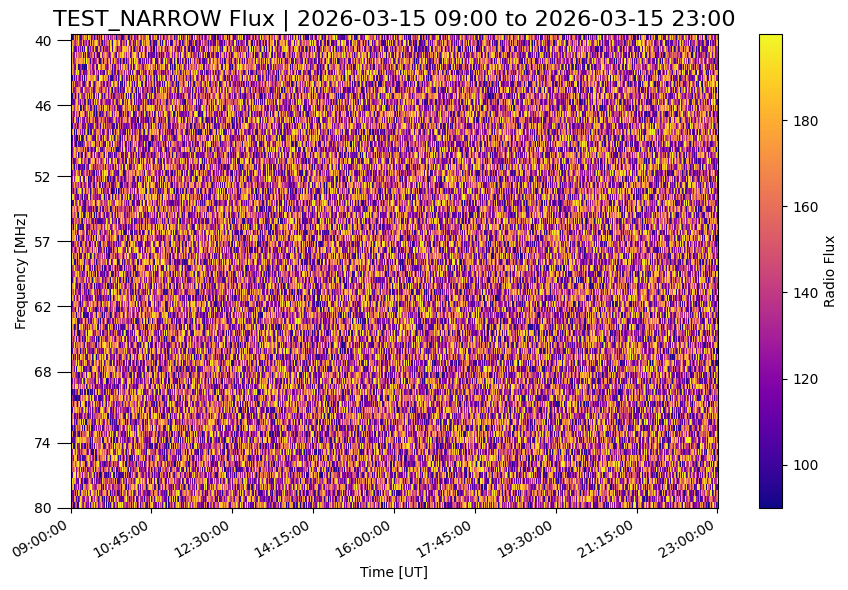

In [13]:
times2 = pd.date_range("2026-03-15 09:00", "2026-03-15 23:00", freq="1min")
freqs2 = np.arange(40, 80, 0.5)   # 80 channels, narrow band
data2  = np.random.uniform(90, 200, size=(len(times2), len(freqs2)))
df_narrow = pd.DataFrame(data2, index=times2, columns=freqs2.astype(str))

fig2 = plot_spectrogram_mpl(
    df_narrow,
    instrument_name="TEST_NARROW",
    start_datetime=times2[0],
    end_datetime=times2[-1],
)
plt.show()

## Test 3 — Very short observation (< 1 hour)
Time format switches to `%H:%M:%S` — rotation should still apply.

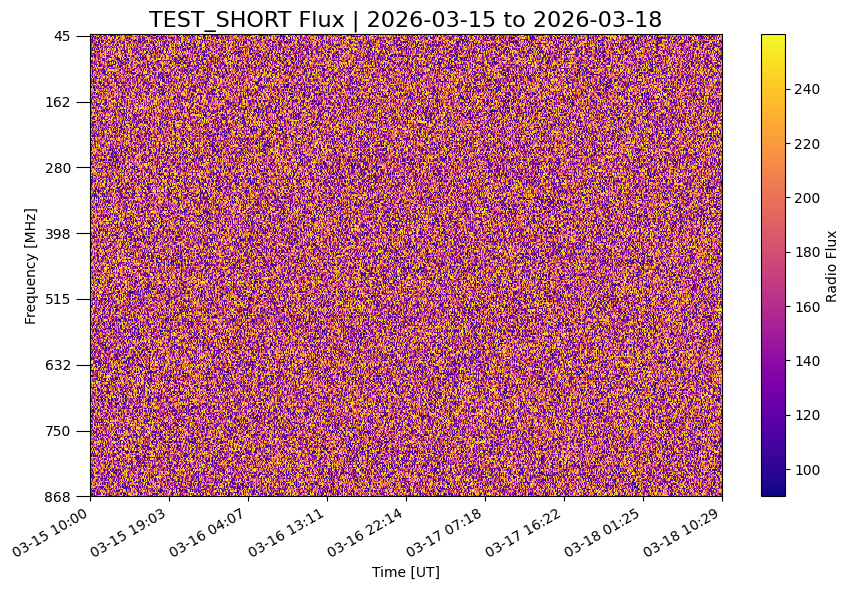

In [15]:
times3 = pd.date_range("2026-03-15 10:00", "2026-03-18 10:30", freq="10s")
freqs3 = np.arange(45, 870, 2.5)
data3  = np.random.uniform(90, 260, size=(len(times3), len(freqs3)))
df_short = pd.DataFrame(data3, index=times3, columns=freqs3.astype(str))

fig3 = plot_spectrogram_mpl(
    df_short,
    instrument_name="TEST_SHORT",
    start_datetime=times3[0],
    end_datetime=times3[-1],
)
plt.show()